In [2]:
!python -m pip install nrlmsise00
!python -m pip install -U 'nrlmsise00[dataset]'
!python -m pip install spaceweather

     |████████████████████████████████| 90 kB 3.9 MB/s 
     |████████████████████████████████| 887 kB 5.3 MB/s 


In [3]:
import numpy as np
import matplotlib.pyplot as plt 
from nrlmsise00.dataset import msise_4d
from datetime import datetime
import spaceweather as sw
sw.update_data()

/usr/local/lib/python3.7/dist-packages/nrlmsise00/dataset/__init__.py:27: UserWarning: The xarray 4d interface is experimental.
  warn("The xarray 4d interface is experimental.", UserWarning)


En la clase 4 vimos como usar el modelo de atmósfera empírica NRLMSISE-00.  En este reto nos proponemos usar los datos de ese modelo para comprobar si la atmósfera empírica esta en equilibrio hidrostático o no lo está.

Para ello debemos probar que la ecuación diferencial ∇ p = f es válida a distintas alturas en la atmósfera y en distintos lugares de la Tierra.  Sin embargo, tenemos el "inconveniente" (o la oportunidad) de que el modelo NRLMSISE-00 no entrega el valor de la presión atmosférica; solo el valor de la densidad, la composición atmosférica y la temperatura a una determinada altura sobre la superficie.  El aire tampoco es un gas sencillo.  Si bien se puede asumir que es un gas ideal, puede ser mejor trabajar con una ecuación de estado de gas real.

## 1. 
Pararse en un punto sobre el ecuador, en una fecha dada.  Usar el paquete nrlmsise00 para recuperar a distintas alturas los valores de la densidad, temperatura y composición del aire (ver el manual del paquete para saber cómo se entrega la composición).

In [168]:
hmax=20e3 # m
zs=np.linspace(0,hmax,100) # m
ds = msise_4d(datetime(2021,4,12,0,0,0),zs/1e3,[0],[0])

In [169]:
ds

<xarray.Dataset>
Dimensions:  (alt: 100, lat: 1, lon: 1, time: 1)
Coordinates:
  * time     (time) datetime64[ns] 2021-04-12
  * alt      (alt) float64 0.0 0.202 0.404 0.6061 ... 19.39 19.6 19.8 20.0
  * lat      (lat) int64 0
  * lon      (lon) int64 0
Data variables: (12/15)
    He       (time, alt, lat, lon) float64 1.284e+14 1.261e+14 ... 1.039e+13
    O        (time, alt, lat, lon) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    N2       (time, alt, lat, lon) float64 1.913e+19 1.88e+19 ... 1.548e+18
    O2       (time, alt, lat, lon) float64 5.133e+18 5.042e+18 ... 4.152e+17
    Ar       (time, alt, lat, lon) float64 2.289e+17 2.248e+17 ... 1.851e+16
    rho      (time, alt, lat, lon) float64 0.001177 0.001156 ... 9.522e-05
    ...       ...
    Texo     (time, alt, lat, lon) float64 1.027e+03 1.027e+03 ... 1.027e+03
    Talt     (time, alt, lat, lon) float64 300.2 298.7 297.2 ... 205.7 206.3
    lst      (time, lon) float64 0.0
    Ap       (time) int32 4
    f107     (time) float64 71.9
    f107a    (time) float64 74.6

In [170]:
He=np.array(ds['He']).flatten()
O=np.array(ds['O']).flatten()
N2=np.array(ds['N2']).flatten()
O2=np.array(ds['O2']).flatten()
Ar=np.array(ds['Ar']).flatten()
N=np.array(ds['N']).flatten()
H=np.array(ds['H']).flatten()

#Temperatura
Ts=np.array(ds['Talt']).flatten() 

#Densidad
ρs=np.array(ds["rho"]).flatten()*1e3

In [171]:
uma=1.6605402e-27 #de umas a kg

#Masas de los elementos que componen la atmósfera en umas
mHe=4.002602*uma
mO=15.99*uma
mN2=14.0067*2*uma
mO2=15.99*2*uma
mAr=39.948*uma
mH=1.00784*uma
mN=14.0067*uma

#Densidad en Kg/m3
rhoHe=mHe*He*1e6
rhoO=mO*O*1e6
rhoN2=mN2*N2*1e6
rhoO2=mO2*O2*1e6
rhoAr=mAr*Ar*1e6
rhoH=mH*H*1e6
rhoN=mN*N*1e6

(-50.0, 50.0)

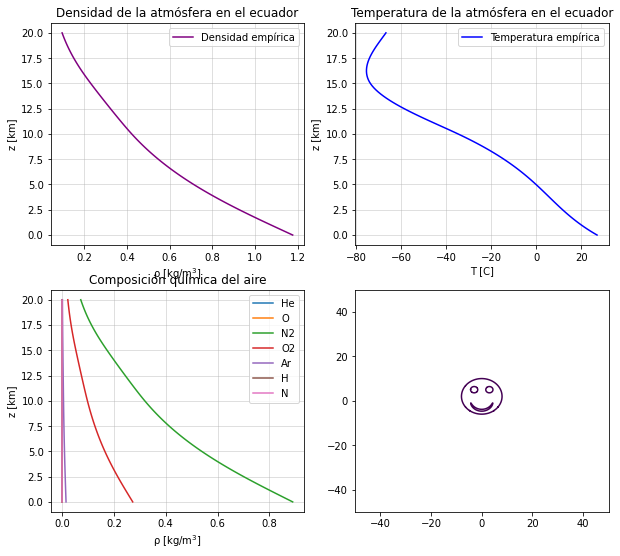

In [172]:
fig, ax = plt.subplots(2, 2,figsize=(10,9))


ax[0,0].plot(ρs,zs/1e3,color='purple',label='Densidad empírica')
ax[0,0].legend()
ax[0,0].set_title("Densidad de la atmósfera en el ecuador")
ax[0,0].set_xlabel("ρ [kg/m$^3$]")
ax[0,0].set_ylabel("z [km]")
ax[0,0].grid(alpha=0.5)

ax[0,1].plot(Ts-273.15,zs/1e3,color='blue',label='Temperatura empírica')
ax[0,1].legend()
ax[0,1].set_title("Temperatura de la atmósfera en el ecuador")
ax[0,1].set_xlabel("T [C]")
ax[0,1].set_ylabel("z [km]")
ax[0,1].grid(alpha=0.5)

ax[1,0].plot(rhoHe,zs/1e3,label='He')
ax[1,0].plot(rhoO,zs/1e3,label='O')
ax[1,0].plot(rhoN2,zs/1e3,label='N2')
ax[1,0].plot(rhoO2,zs/1e3,label='O2')
ax[1,0].plot(rhoAr,zs/1e3,label='Ar')
ax[1,0].plot(rhoH,zs/1e3,label='H')
ax[1,0].plot(rhoN,zs/1e3,label='N')
ax[1,0].legend()
ax[1,0].set_title("Composición química del aire")
ax[1,0].set_xlabel("ρ [kg/m$^3$]")
ax[1,0].set_ylabel("z [km]")
ax[1,0].grid(alpha=0.5)

y=x=np.arange(-8,11,.1)
x,y=np.meshgrid(x,y)
ax[1,1].contour(x,y,(x*x*(x**2+2*y*y-y-40)+y*y*(y*y-y-40)+23*y+403)*((x+3)**2+(y-5)**2-2)*((x-3)**2+(y-5)**2-2)*(x*x+(y-2)**2-64),[0])
ax[1,1].set_xlim([-50, 50])
ax[1,1].set_ylim([-50, 50])

#2. 
Calcular con la composición en cada punto, el valor del peso molecular promedio (Mmol o μ) de la mezcla de gases.

El aire es una composición de varios elementos, por lo tanto, como vimos en clase para el plasma, para calcular el peso molecular promedio es necesario la fracción de masa de cada elemento. Anteriormente calculamos la densidad de cada elemento en el aire y el modelo nos entrega la densidad promedio, por ende, para calcular el porcentaje de cada elemento hacemos la razón entre estos dos:

$$X_i=\frac{\rho_{i}}{\rho}$$

Siendo $X_i$ la fracción de masa del elemento $i$, $\rho_{i}$ la densidad del elemento $i$ y $\rho$ la densidad promedio del aire.

Luego, con esto, el peso molecular del aire es la suma de los productos de la fracción del gas multiplicado por su peso atómico.

$$M_{mol} = X_1m_1 + X_2m_2 + X_3m_3 + ... $$

$$M_{mol}=\sum_{i} X_im_i$$

Siendo $m_i$ la masa atómica del elemento $i$

In [173]:
#fracción de masa de los elementos
XHe=rhoHe/ρs
XO=rhoO/ρs
XN2=rhoN2/ρs
XO2=rhoO2/ρs
XAr=rhoAr/ρs
XH=rhoH/ρs
XN=rhoN/ρs

Mmol=XHe*mHe+XO*mO+XN2*mN2+XO2*mO2+XAr*mAr+XH*mH+XN*mN

print("El peso molecular promedio del aire es",Mmol[0],"Kg")
print("El peso molecular promedio del aire es",Mmol[0]/uma,"g/mol")

El peso molecular promedio del aire es 4.832254604613027e-26 Kg
El peso molecular promedio del aire es 29.100497564666167 g/mol


#3.
Usando la ecuación de estado de gas ideal calcular la presión a cada altura usando los datos de temperatura, densida y masa molar obtenidos en 1 y 2.

En clase vimos que la ecuación de los gases ideales se puede escribir como:

$$P=\frac{R~T~\rho}{M_{mol}}$$

Reemplacemos todos los valores que hemos obtenido aquí.

Text(0, 0.5, 'z [km]')

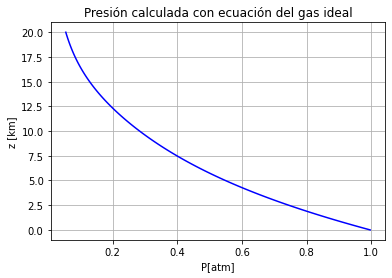

In [174]:
R=8.205746e-5 #atm m^3/mol K

Psideal = R*Ts*ρs*1000*uma/Mmol #multiplicamos ρs por mil para convertirlo a g/m^3 y Mmol lo dividimos por uma para convertirlo a g/mol

plt.plot(Psideal,zs/1e3,color='blue')
plt.title("Presión calculada con ecuación del gas ideal")
plt.grid()
plt.xlabel("P[atm]")
plt.ylabel("z [km]")

#4. 
Calcular numéricamente el gradiente de la presión en cada altura (solo la componente z) y compararlo con la densidad de fuerza de cuerpo experimentado por el gas. ¿Está la atmósfera en equilibrio hidrostático?.

Text(0, 0.5, 'z [km]')

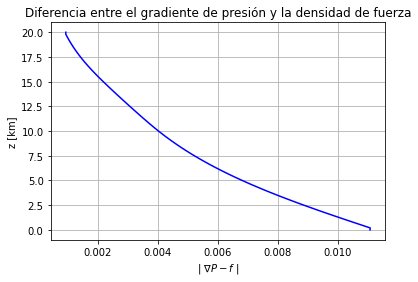

In [175]:
#Densidad de fuerza
mtierra=5.972e24
G=6.67384e-11
radio=6370000
r=radio+zs
g=G*mtierra/(r**2)
f=-g*ρs/1000

#Gradiente de la presión
gradientePsideal=np.gradient(Psideal)

plt.plot(f-gradientePsideal,zs/1e3,color='blue')
plt.title("Diferencia entre el gradiente de presión y la densidad de fuerza")
plt.grid()
plt.xlabel('| ∇$P-f$ |')
plt.ylabel("z [km]")

#5.
 Repetir el cálculo 2 y 3 pero usando una ecuación de estado más realista, por ejemplo la ecuación de estado de Van der Waals como explican en la ecuación (10) del artículo adjunto.

La ecuación de Van de Walls encontrada en el articulo es:

$$\left[ P + I \left( \frac{n}{V} \right)^2 \right] \left[ V - nD \right] = nRT$$

Donde I y D son constantes del problema relacionadas con la medida de atracción entre las partículas. 

Ya que no contamos ni con el valor de n y V haremos una manipuación algebraica para obtener la ecuación de Van der Waals en términos conocidos

$$\left[ P + I \left( \frac{n}{V} \frac{M_{mol}}{M_{mol}} \right)^2 \right] \left[ \frac{V}{n} - D \right] = RT$$

$$\left[ P + I \left( \frac{\rho}{M_{mol}} \right)^2 \right] \left[ \frac{V}{n} \frac{M_{mol}}{M_{mol}} - D \right] = RT$$

$$\left[ P + I \left( \frac{\rho}{M_{mol}} \right)^2 \right] \left[  \frac{M_{mol}}{\rho} - D \right] = RT$$

$$\left[ P + I \left( \frac{\rho}{M_{mol}} \right)^2 \right] \left[  \frac{M_{mol}-D \rho}{\rho} \right] = RT$$

$$\left[ P + I \left( \frac{\rho}{M_{mol}} \right)^2 \right] \left[  \frac{M_{mol}-D \rho}{\rho} \right] = RT$$

$$\left[ P + I \left( \frac{\rho}{M_{mol}} \right)^2 \right]  =  \frac{RT \rho}{M_{mol}-D \rho}$$

$$P    =  \frac{RT \rho}{M_{mol}-D \rho} - I \left( \frac{\rho}{M_{mol}} \right)^2$$




Text(0, 0.5, 'z [km]')

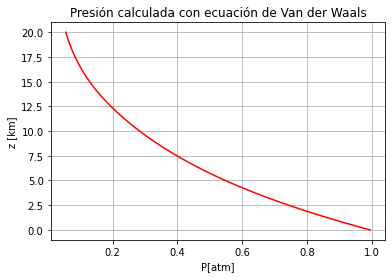

In [176]:
R1=8.3144661815324 #m3 Pa / (K mol)
D=3.55832e-5 #m3/mol
I=1.50054e-1 #Jm3/mol

a = (R1*Ts*ρs*1000)/((Mmol/uma)-D*ρs*1000)
b = I*(((ρs*1000*uma)/(Mmol))**2)
Psvdw = (a-b)*9.8692e-6 #atm

plt.plot(Psvdw,zs/1e3,color='red')
plt.title("Presión calculada con ecuación de Van der Waals")
plt.grid()
plt.xlabel("P[atm]")
plt.ylabel("z [km]")

Text(0, 0.5, 'z [km]')

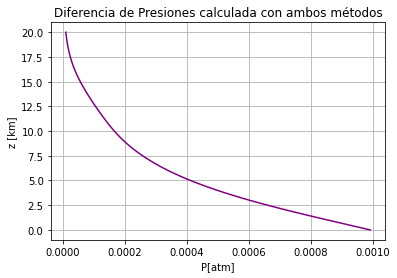

In [177]:
plt.plot(Psideal-Psvdw,zs/1e3,color='purple')
plt.title("Diferencia de Presiones calculada con ambos métodos")
plt.grid()
plt.xlabel("P[atm]")
plt.ylabel("z [km]")

#6
Repita lo anterior en fechas y horas distintas del día. Hágalo también en una latitud cercana o en el polo norte o en el polo sur. Finalmente pruebe hacerlo en una latitud intermedia.

In [178]:
#Distintas horas
ds1 = msise_4d(datetime(2021,4,12,6,0,0),zs/1e3,[0],[0])
ds2 = msise_4d(datetime(2021,7,27,0,0,0),zs/1e3,[0],[0])
ds3 = msise_4d(datetime(2021,10,4,0,0,0),zs/1e3,[0],[0])

#En el polo norte
dp = msise_4d(datetime(2021,4,12,6,0,0),zs/1e3,[90],[0])
dp1 = msise_4d(datetime(2021,7,27,6,0,0),zs/1e3,[90],[0])
dp2 = msise_4d(datetime(2021,10,4,0,0,0),zs/1e3,[90],[0])
dp3 = msise_4d(datetime(2021,1,15,18,0,0),zs/1e3,[90],[0])

#latitud intermedia
di = msise_4d(datetime(2021,4,12,6,0,0),zs/1e3,[45],[0])
di1 = msise_4d(datetime(2021,7,27,6,0,0),zs/1e3,[45],[0])
di2 = msise_4d(datetime(2021,10,4,12,0,0),zs/1e3,[45],[0])
di3 = msise_4d(datetime(2021,1,15,18,0,0),zs/1e3,[45],[0])

fechas = [ds1,ds2,ds3,dp,dp1,dp2,dp3,di,di1,di2,di3]


In [179]:
pesos = []
densidades=np.zeros((len(zs),len(fechas)))
temperaturas=np.zeros((len(zs),len(fechas)))
Presionesgi=np.zeros((len(zs),len(fechas)))
Presionesvdw=np.zeros((len(zs),len(fechas)))

In [180]:
for i in range(len(fechas)):

  He=np.array(fechas[i]['He']).flatten()
  O=np.array(fechas[i]['O']).flatten()
  N2=np.array(fechas[i]['N2']).flatten()
  O2=np.array(fechas[i]['O2']).flatten()
  Ar=np.array(fechas[i]['Ar']).flatten()
  N=np.array(fechas[i]['N']).flatten()
  H=np.array(fechas[i]['H']).flatten()

    #Temperatura
  Ts=np.array(fechas[i]['Talt']).flatten() 
  temperaturas[:,i]=Ts

  #Densidad
  ρs=np.array(fechas[i]["rho"]).flatten()*1e3
  densidades[:,i]=ρs

  #Densidad en Kg/m3
  rhoHe=mHe*He*1e6
  rhoO=mO*O*1e6
  rhoN2=mN2*N2*1e6
  rhoO2=mO2*O2*1e6
  rhoAr=mAr*Ar*1e6
  rhoH=mH*H*1e6
  rhoN=mN*N*1e6

  #fraccciones de masa de cada elemento
  XHe=rhoHe/ρs
  XO=rhoO/ρs
  XN2=rhoN2/ρs
  XO2=rhoO2/ρs
  XAr=rhoAr/ρs
  XH=rhoH/ρs
  XN=rhoN/ρs

  Mmol=XHe*mHe+XO*mO+XN2*mN2+XO2*mO2+XAr*mAr+XH*mH+XN*mN
  pesos.append(Mmol[0])

  R=8.205746e-5 #atm m^3/mol K

  Psideal = R*Ts*ρs*1000*uma/Mmol #multiplicamos ρs por mil para convertirlo a g/m^3 y Mmol lo dividimos por uma para convertirlo a g/mol
  Presionesgi[:,i]=Psideal


  R1=8.3144661815324 #m3 Pa / (K mol)
  D=3.55832e-5 #m3/mol
  I=1.50054e-1 #Jm3/mol

  a = (R1*Ts*ρs*1000)/((Mmol/uma)-D*ρs*1000)
  b = I*(((ρs*1000*uma)/(Mmol))**2)
  Psvdw = (a-b)*9.8692e-6 #atm
  Presionesvdw[:,i]=Psvdw



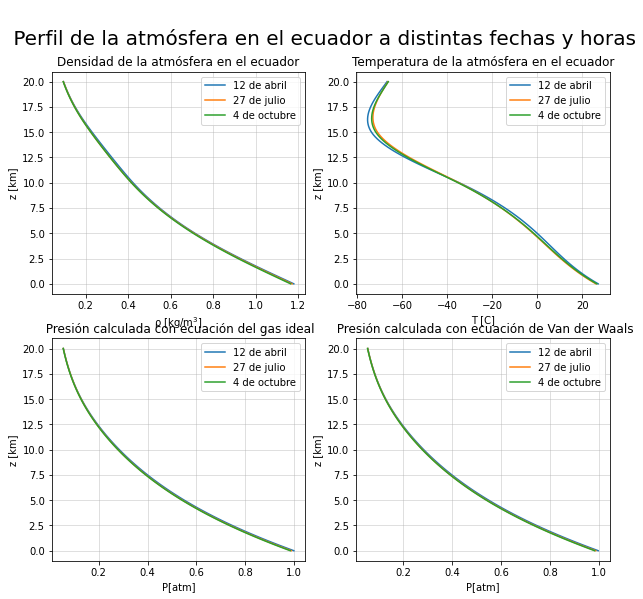

In [181]:
fig, ax = plt.subplots(2, 2,figsize=(10,9))


ax[0,0].plot(densidades[:,0],zs/1e3,label='12 de abril')
ax[0,0].plot(densidades[:,1],zs/1e3,label='27 de julio')
ax[0,0].plot(densidades[:,2],zs/1e3,label='4 de octubre')
ax[0,0].legend()
ax[0,0].set_title("Densidad de la atmósfera en el ecuador")
ax[0,0].set_xlabel("ρ [kg/m$^3$]")
ax[0,0].set_ylabel("z [km]")
ax[0,0].grid(alpha=0.5)

ax[0,1].plot(temperaturas[:,0]-273.15,zs/1e3,label='12 de abril')
ax[0,1].plot(temperaturas[:,1]-273.15,zs/1e3,label='27 de julio')
ax[0,1].plot(temperaturas[:,2]-273.15,zs/1e3,label='4 de octubre')
ax[0,1].legend()
ax[0,1].set_title("Temperatura de la atmósfera en el ecuador")
ax[0,1].set_xlabel("T [C]")
ax[0,1].set_ylabel("z [km]")
ax[0,1].grid(alpha=0.5)

ax[1,0].plot(Presionesgi[:,0],zs/1e3,label='12 de abril')
ax[1,0].plot(Presionesgi[:,1],zs/1e3,label='27 de julio')
ax[1,0].plot(Presionesgi[:,2],zs/1e3,label='4 de octubre')
ax[1,0].legend()
ax[1,0].set_title("\n Presión calculada con ecuación del gas ideal")
ax[1,0].set_xlabel("P[atm]")
ax[1,0].set_ylabel("z [km]")
ax[1,0].grid(alpha=0.5)

ax[1,1].plot(Presionesvdw[:,0],zs/1e3,label='12 de abril')
ax[1,1].plot(Presionesvdw[:,1],zs/1e3,label='27 de julio')
ax[1,1].plot(Presionesvdw[:,2],zs/1e3,label='4 de octubre')
ax[1,1].legend()
ax[1,1].set_title("\n Presión calculada con ecuación de Van der Waals")
ax[1,1].set_xlabel("P[atm]")
ax[1,1].set_ylabel("z [km]")
ax[1,1].grid(alpha=0.5)

fig.suptitle(f'\n Perfil de la atmósfera en el ecuador a distintas fechas y horas', fontsize=20)
plt.show()

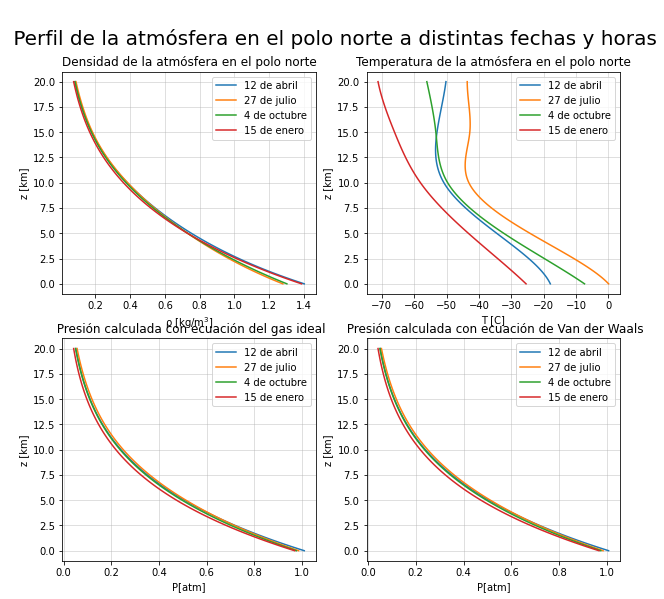

In [182]:
fig, ax = plt.subplots(2, 2,figsize=(10,9))

ax[0,0].plot(densidades[:,3],zs/1e3,label='12 de abril')
ax[0,0].plot(densidades[:,4],zs/1e3,label='27 de julio')
ax[0,0].plot(densidades[:,5],zs/1e3,label='4 de octubre')
ax[0,0].plot(densidades[:,6],zs/1e3,label="15 de enero")
ax[0,0].legend()
ax[0,0].set_title("Densidad de la atmósfera en el polo norte")
ax[0,0].set_xlabel("ρ [kg/m$^3$]")
ax[0,0].set_ylabel("z [km]")
ax[0,0].grid(alpha=0.5)

ax[0,1].plot(temperaturas[:,3]-273.15,zs/1e3,label='12 de abril')
ax[0,1].plot(temperaturas[:,4]-273.15,zs/1e3,label='27 de julio')
ax[0,1].plot(temperaturas[:,5]-273.15,zs/1e3,label='4 de octubre')
ax[0,1].plot(temperaturas[:,6]-273.15,zs/1e3,label='15 de enero')
ax[0,1].legend()
ax[0,1].set_title("Temperatura de la atmósfera en el polo norte")
ax[0,1].set_xlabel("T [C]")
ax[0,1].set_ylabel("z [km]")
ax[0,1].grid(alpha=0.5)

ax[1,0].plot(Presionesgi[:,3],zs/1e3,label='12 de abril')
ax[1,0].plot(Presionesgi[:,4],zs/1e3,label='27 de julio')
ax[1,0].plot(Presionesgi[:,5],zs/1e3,label='4 de octubre')
ax[1,0].plot(Presionesgi[:,6],zs/1e3,label='15 de enero')
ax[1,0].legend()
ax[1,0].set_title("\n Presión calculada con ecuación del gas ideal")
ax[1,0].set_xlabel("P[atm]")
ax[1,0].set_ylabel("z [km]")
ax[1,0].grid(alpha=0.5)

ax[1,1].plot(Presionesvdw[:,3],zs/1e3,label='12 de abril')
ax[1,1].plot(Presionesvdw[:,4],zs/1e3,label='27 de julio')
ax[1,1].plot(Presionesvdw[:,5],zs/1e3,label='4 de octubre')
ax[1,1].plot(Presionesvdw[:,6],zs/1e3,label='15 de enero')
ax[1,1].legend()
ax[1,1].set_title("\n Presión calculada con ecuación de Van der Waals")
ax[1,1].set_xlabel("P[atm]")
ax[1,1].set_ylabel("z [km]")
ax[1,1].grid(alpha=0.5)

fig.suptitle(f'\n Perfil de la atmósfera en el polo norte a distintas fechas y horas', fontsize=20)
plt.show()

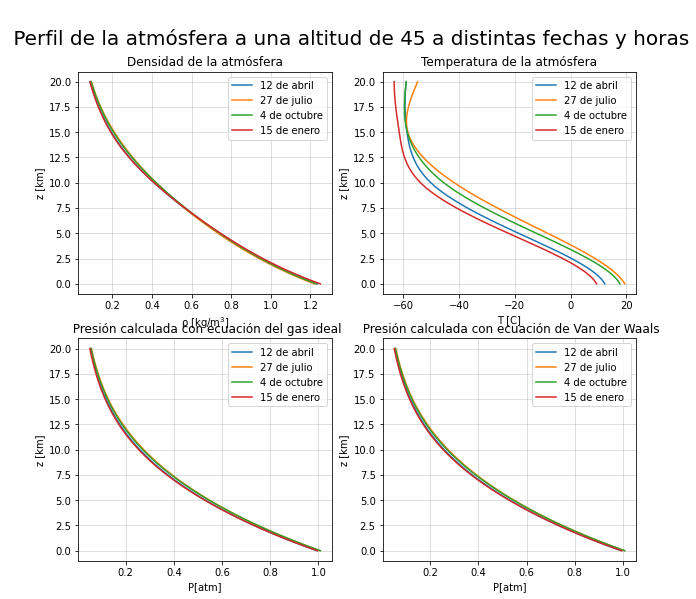

In [183]:
fig, ax = plt.subplots(2, 2,figsize=(10,9))

ax[0,0].plot(densidades[:,7],zs/1e3,label='12 de abril')
ax[0,0].plot(densidades[:,8],zs/1e3,label='27 de julio')
ax[0,0].plot(densidades[:,9],zs/1e3,label='4 de octubre')
ax[0,0].plot(densidades[:,10],zs/1e3,label='15 de enero')
ax[0,0].legend()
ax[0,0].set_title("Densidad de la atmósfera")
ax[0,0].set_xlabel("ρ [kg/m$^3$]")
ax[0,0].set_ylabel("z [km]")
ax[0,0].grid(alpha=0.5)

ax[0,1].plot(temperaturas[:,7]-273.15,zs/1e3,label='12 de abril')
ax[0,1].plot(temperaturas[:,8]-273.15,zs/1e3,label='27 de julio')
ax[0,1].plot(temperaturas[:,9]-273.15,zs/1e3,label='4 de octubre')
ax[0,1].plot(temperaturas[:,10]-273.15,zs/1e3,label='15 de enero')
ax[0,1].legend()
ax[0,1].set_title("Temperatura de la atmósfera")
ax[0,1].set_xlabel("T [C]")
ax[0,1].set_ylabel("z [km]")
ax[0,1].grid(alpha=0.5)

ax[1,0].plot(Presionesgi[:,7],zs/1e3,label='12 de abril')
ax[1,0].plot(Presionesgi[:,8],zs/1e3,label='27 de julio')
ax[1,0].plot(Presionesgi[:,9],zs/1e3,label='4 de octubre')
ax[1,0].plot(Presionesgi[:,10],zs/1e3,label='15 de enero')
ax[1,0].legend()
ax[1,0].set_title("\n Presión calculada con ecuación del gas ideal")
ax[1,0].set_xlabel("P[atm]")
ax[1,0].set_ylabel("z [km]")
ax[1,0].grid(alpha=0.5)

ax[1,1].plot(Presionesvdw[:,7],zs/1e3,label='12 de abril')
ax[1,1].plot(Presionesvdw[:,8],zs/1e3,label='27 de julio')
ax[1,1].plot(Presionesvdw[:,9],zs/1e3,label='4 de octubre')
ax[1,1].plot(Presionesvdw[:,10],zs/1e3,label='15 de enero')
ax[1,1].legend()
ax[1,1].set_title("\n Presión calculada con ecuación de Van der Waals")
ax[1,1].set_xlabel("P[atm]")
ax[1,1].set_ylabel("z [km]")
ax[1,1].grid(alpha=0.5)

fig.suptitle(f'\n Perfil de la atmósfera a una altitud de 45 a distintas fechas y horas', fontsize=20)
plt.show()

Conclusión:

Como se puede observar en las gráficas hay cambios más significativos de las propiedades de la atmósfera a mayor altitud a lo largo del año, esto es debido a las estaciones, esto afecta en gran medida a la temperatura, generando esto cambios en la presión y densidad.

También se puede notar que la diferencia de presión calculada con ambos métodos nos es muy significativa variando unicamente a partir de la tercer cifra significativa, sin embargo se puede evidenciar que este diferencia siempre es positiva, mostrando que la presión calculada con la ecuación del gas ideal es mayor.

Se intento realizar el efecto de la aceleración centrífuga en el aire, pero lamentablemente fue demasiado complejo y no fuí capaz, no obstante, esto lo podemos analizar con el grafico de cambio del gradiente de Temperatura con la densidad de fuerza, donde nos muestra que hay una pequeña diferencia entre ambos, es decir, no hay equilibrio hidrostático, pero es más complejo que eso. Cuando las isóbaras presentan curvatura, la partícula de aire se mueve junto con ellas siguiendo una trayectoria curvada, de esta manera la partícula es sometida a una fuerza centrífuga dirigida siempre desde una presión menor ubicada en el centro de curvatura de la trayectoria a una mayor. Esta fuerza es proporcional al cuadrado de la velocidad del aire, e inversamente proporcional al radio de curvatura de la trayectoria. Por el contrario la fuerza de presión actúa dirigiendo la partícula a una presión menor. De esta manera, ambas fuerzas se oponen generando que la partícula no este en equilibrio y generando el error encontrado en las gráficas.